# Análisis ConnectaTel

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
plans = pd.read_csv("plans.csv")
users = pd.read_csv("users_latam.csv")
usage = pd.read_csv("usage.csv")

In [5]:
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [8]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      str    
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes


In [10]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


In [11]:
usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB


In [12]:
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Diagnóstico de valores nulos**

* **City (11,73%)**: presenta una proporción moderada de valores faltantes. Se recomienda investigar la causa de los nulos y evaluar una estrategia de imputación o la creación de una categoría "Desconocido" si corresponde.
* **Churn Date (88,35%)**: la mayoría de los valores son nulos.  Sin embargo, estos nulos parecen tener significado de negocio, ya que indican usuarios que continúan activos y no han cancelado el servicio. Por este motivo, los valores ausentes no se consideran errores de calidad. Se recomienda conservar la columna.
* **Date (0,13%)**: la proporción de nulos es muy baja. Se pueden mantener como nulos o imputar según el contexto del análisis.
* **Duration (55,19%)**: presenta una alta proporción de valores faltantes. Es necesario investigar el origen de los nulos y evaluar si la variable aporta valor suficiente para justificar una imputación.
* **Length (44,74%)**: posee una cantidad significativa de valores faltantes. Se recomienda analizar la relación de los nulos con otras variables antes de decidir una estrategia de imputación o eliminación.

In [14]:
users["user_id"].nunique()

4000

In [15]:
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [16]:
users['age'].isin([-999]).sum()

np.int64(55)

- La columna 'user_id' contiene 4.000 valores únicos sobre 4.000 registros, por lo que funciona correctamente como identificador único de cada usuario. No se observan duplicados y no aporta información analítica más allá de la identificación de registros.
- La columna 'age' muestra un valor mínimo de -999, lo que resulta imposible para una edad y sugiere la presencia de un valor erróneo o utilizado como marcador de dato faltante. Será necesario tratar este valor durante la limpieza de datos antes de realizar análisis posteriores.

In [17]:
usage[["id","user_id"]].nunique()

id         40000
user_id     3999
dtype: int64

In [18]:
usage[["duration","length"]].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- La columna id actúa como identificador único de los registros de uso, mientras que user_id permite vincular cada registro con un usuario. Se observa que existen 40.000 registros de uso asociados a 3.999 usuarios, lo que indica que al menos un usuario no posee registros de actividad o presenta datos faltantes en esta tabla.
- Las columnas duration y length presentan una gran dispersión y una cantidad importante de valores faltantes. Es necesario investigar la relación de los nulos con otras variables.

In [19]:
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f'\n### {col.upper()} ###')

    print('\nResumen:')
    print(users[col].describe())

    print('\nDistribución (%):')
    print((users[col].value_counts(normalize=True) * 100).round(2))


### CITY ###

Resumen:
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Distribución (%):
city
Bogotá      22.88
CDMX        20.67
Medellín    17.45
GDL         12.74
Cali        12.01
MTY         11.53
?            2.72
Name: proportion, dtype: float64

### PLAN ###

Resumen:
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

Distribución (%):
plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64


 City

    - Tiene 7 ciudades distintas.
    - Bogotá es la ciudad más frecuente con 808 usuarios.
    - Existen 469 valores nulos (4000 - 3531).
    - Se identificó la presencia de la categoría ? en la variable city. Dado que no representa una ciudad válida, se considera un posible valor faltante codificado como texto. Se recomienda reemplazarlo por NaN para un tratamiento consistente de los datos faltantes.
    - La distribución parece relativamente equilibrada entre las ciudades principales.

Plan

    - Solo tiene 2 categorías: Básico y Premium.
    - El plan Básico es el más utilizado (2595 usuarios).
    - No presenta valores faltantes.
    - Hay cierto desbalance, aunque ambos planes tienen representación suficiente para comparaciones

In [20]:
usage['type'].value_counts()

type
text    22092
call    17908
Name: count, dtype: int64

- La columna 'type' contiene dos categorías: text (22.092 registros) y call (17.908 registros).
- La distribución es relativamente equilibrada, aunque los mensajes de texto representan una proporción ligeramente mayor del total de eventos.
- No se observan categorías inesperadas ni valores inconsistentes


**Conclusión y plan de acción**

Durante la exploración de los datos se identificaron distintos problemas de calidad que deberán abordarse antes de realizar análisis más profundos o construir modelos. En la variable age se detectó el valor -999, el cual constituye un valor inválido o sentinel utilizado probablemente para representar información faltante. Se recomienda reemplazarlo por la mediana.

Asimismo, en la variable city se identificó la categoría ?, que no representa una ciudad válida y podría corresponder a un valor faltante codificado incorrectamente. Se recomienda convertir estos registros a NaN y evaluar posteriormente una estrategia de imputación o categorización como "Desconocido".

Por otro lado, los valores nulos observados en las variables duration y length parecen estar asociados al tipo de registro (call o text), por lo que no deben considerarse errores ni imputarse automáticamente. Estos nulos son consistentes con la naturaleza de los datos y deberían conservarse.

Finalmente, se detectó una discrepancia entre la cantidad de usuarios únicos en las tablas users y usage, por lo que se recomienda identificar el usuario sin registros de actividad y validar si se trata de una situación esperada o de un problema de integridad de los datos

In [21]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [22]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [23]:
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

La columna 'reg_date' fue convertida correctamente al tipo fecha y se analizó la distribución de los años registrados. Se identificaron registros correspondientes a los años 2022, 2023 y 2024, que se encuentran dentro del rango esperado para el dataset. Sin embargo, también se detectaron 40 registros con fecha de registro en el año 2026.

In [24]:
usage['date'].dt.year.value_counts().sort_index()

date
2024.0    39950
Name: count, dtype: int64

Todos los registros con fecha válida pertenecen al año 2024.
No se detectan años futuros ni fuera del rango esperado.
Existen 50 registros sin una fecha válida, que se decide mantener como nulos al representar un porcentaje menor al 1% del total.

**Conclusión**

Se detectaron 40 registros con fecha de registro en el año 2026 en la columna reg_date.

Dado que los datos disponibles se limitan al año 2024, estas fechas se consideran inconsistentes y podrían corresponder a errores de captura o carga de datos. Se recomienda revisar dichos registros para determinar si existe un patrón común y corregirlos cuando sea posible. En caso de no poder validar la información, estos registros deberán marcarse como valores inválidos y tratarse durante la etapa de limpieza de datos.

La columna date de la tabla usage fue convertida al tipo fecha y se analizó la distribución de los años registrados. Todos los registros con fecha válida corresponden al año 2024, por lo que no se identificaron años fuera del rango esperado ni fechas futuras.

Sin embargo, se detectaron 50 registros sin una fecha válida, representados como valores nulos (NaT) tras la conversión. Se mantendrán como nulos.

In [25]:
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
users['city'] = users['city'].replace('?', pd.NA)
users['city'].value_counts()

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [27]:
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT 

users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

In [28]:
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False) 

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [29]:
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se analizó la relación entre los valores nulos de `duration` y `length` y la variable `type`. Se observó que los valores faltantes presentan un patrón claro: los registros de tipo `call` contienen información en `duration` pero no en `length`, mientras que los registros de tipo `text` contienen información en `length` pero no en `duration`.

Dado que la ausencia de datos depende de una variable observable (`type`), estos valores ausentes pueden clasificarse como MAR (Missing At Random). Por este motivo, no se recomienda imputarlos ni eliminarlos, ya que reflejan la naturaleza del evento registrado y conservan información relevante para el análisis.

In [30]:
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int) 

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes","is_call": "cant_llamadas","duration": "cant_minutos_llamada"}) 

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left')

In [33]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [34]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe() # Resumen estadístico de las columnas numéricas

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [35]:
(users["plan"].value_counts(normalize=True) * 100).round(2)

plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64

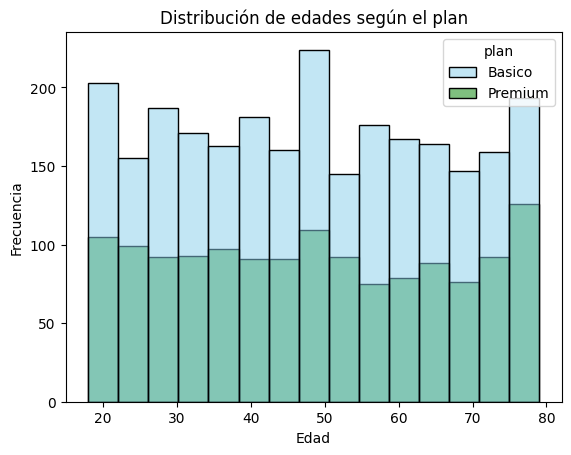

In [36]:
sns.histplot(data=user_profile, x='age', bins=15, hue='plan',palette=['skyblue','green'], kde=False)

plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de edades según el plan')

plt.show()

💡Insights: 
- No se observa un patrón claro entre la edad y el tipo de plan contratado. Los usuarios de los planes Básico y Premium presentan distribuciones de edad similares. La distribución es relativamente uniforme y sin sesgo marcado hacia la derecha o la izquierda.

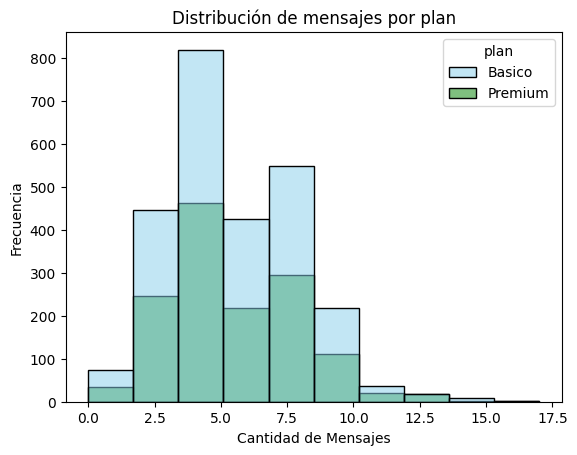

In [37]:
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan',palette=['skyblue','green'], kde=False)

plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de mensajes por plan')

plt.show()# Histograma para visualizar la cant_mensajes

💡Insights: 
- La mayor parte de los usuarios envía entre 3 y 8 mensajes. La distribución presenta un ligero sesgo a la derecha debido a algunos usuarios con una cantidad elevada de mensajes. No se observan diferencias claras entre planes.

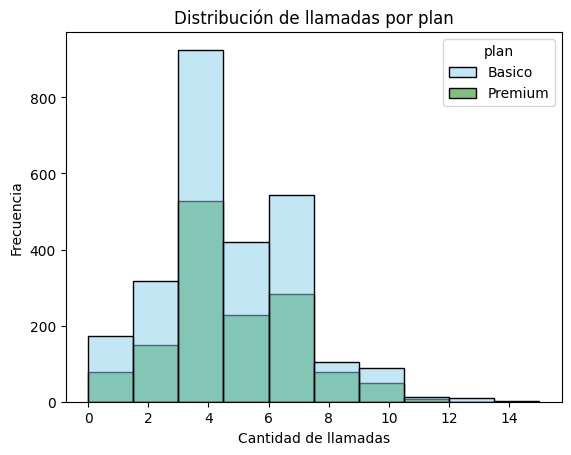

In [38]:
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan',palette=['skyblue','green'], kde=False)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de llamadas por plan')

plt.show()# Histograma para visualizar la cant_llamadas

💡Insights: 
- La mayoría de los usuarios de ambos planes realiza entre 3 y 7 llamadas. No se observan diferencias significativas entre los planes Básico y Premium, ya que ambas distribuciones presentan una forma similar. La distribución muestra un ligero sesgo a la derecha, debido a la presencia de un pequeño grupo de usuarios con una cantidad elevada de llamadas.

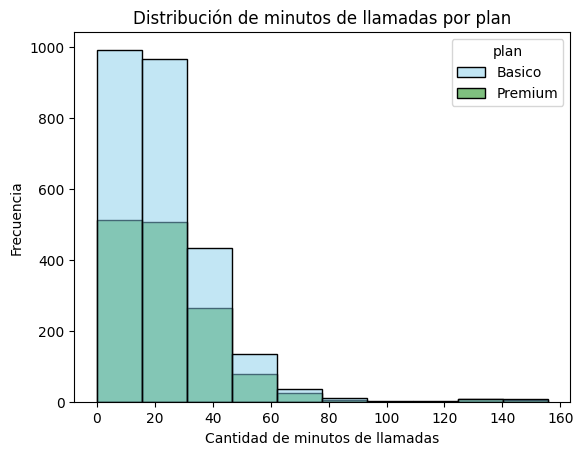

In [39]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan',palette=['skyblue','green'], kde=False)

plt.xlabel('Cantidad de minutos de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de minutos de llamadas por plan')

plt.show()# Histograma para visualizar la cant_minutos_llamada

💡Insights: 
- La mayoría de los usuarios acumula menos de 40 minutos de llamadas, independientemente del plan contratado. No se observan diferencias claras entre los planes Básico y Premium. La distribución presenta un marcado sesgo a la derecha, ya que existen pocos usuarios con consumos excepcionalmente altos que generan una cola larga en la distribución.

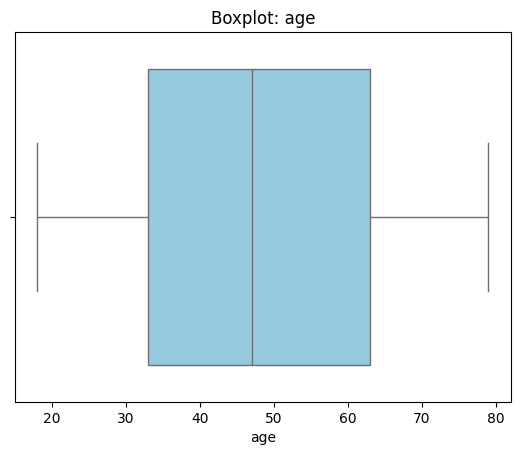

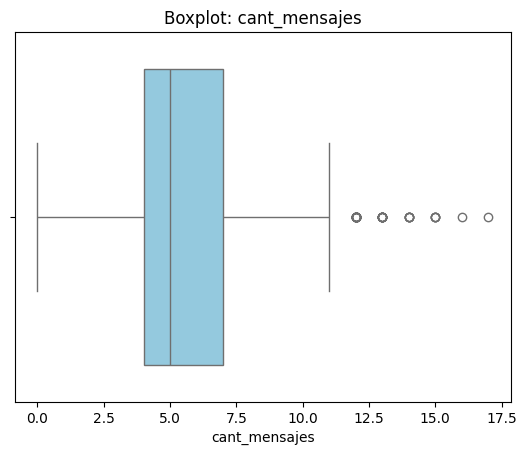

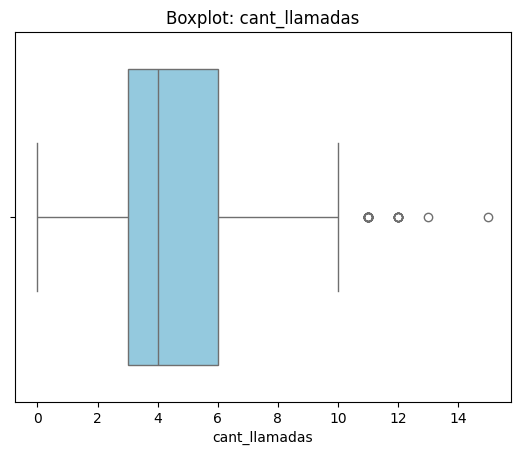

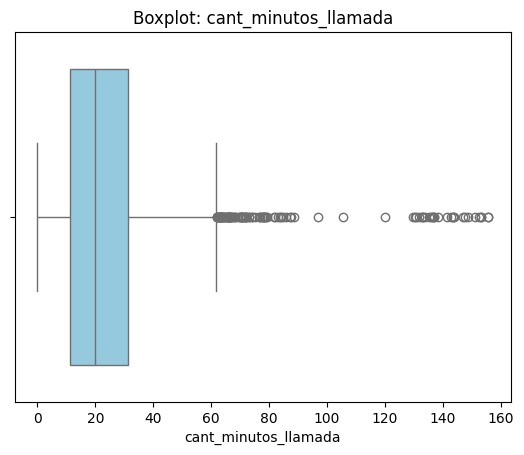

In [40]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta valores atípicos evidentes (una vez corregidos los sentinels como -999). La distribución de edades se mantiene dentro de rangos plausibles
- cant_mensajes: Se observan algunos valores atípicos superiores correspondientes a usuarios con una cantidad inusualmente alta de mensajes. Estos casos deberían investigarse, aunque podrían representar usuarios con un uso intensivo legítimo del servicio.
- cant_llamadas: Presenta algunos valores atípicos superiores correspondientes a usuarios con una cantidad de llamadas significativamente mayor al resto.
- cant_minutos_llamada: Presenta valores atípicos superiores más marcados que las demás variables, asociados a usuarios con consumos excepcionalmente altos de minutos.

In [41]:
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'{col}: Limite Superior = {limite_superior}')

cant_mensajes: Limite Superior = 11.5
cant_llamadas: Limite Superior = 10.5
cant_minutos_llamada: Limite Superior = 61.8575


In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes
El máximo es 17 mensajes.
El límite es 11.5.
La diferencia existe, pero 17 mensajes no parece un valor imposible ni sospechoso.
Conclusión: mantener.

- cant_llamadas
El máximo es 15 llamadas.
El límite es 10.5.
Nuevamente supera el límite, pero no de forma exagerada.
Conclusión: mantener.


- cant_minutos_llamada
El límite es 61.86 minutos.
El máximo es 155.69 minutos.
El máximo es aproximadamente 2.5 veces el límite.
Sin embargo:
No es un valor imposible.
En telecomunicaciones es perfectamente razonable que algunos usuarios hablen mucho más que la mayoría.
La variable ya mostraba una fuerte asimetría a la derecha en el histograma.
Conclusión: mantener.

In [43]:
import numpy as np

condiciones = [(user_profile['cant_llamadas'] < 5)&(user_profile['cant_mensajes'] < 5), (user_profile['cant_llamadas'] < 10)&(user_profile['cant_mensajes'] < 10)]
valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [44]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [45]:
condiciones = [(user_profile['age']< 30),(user_profile['age']< 60)]
valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [46]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


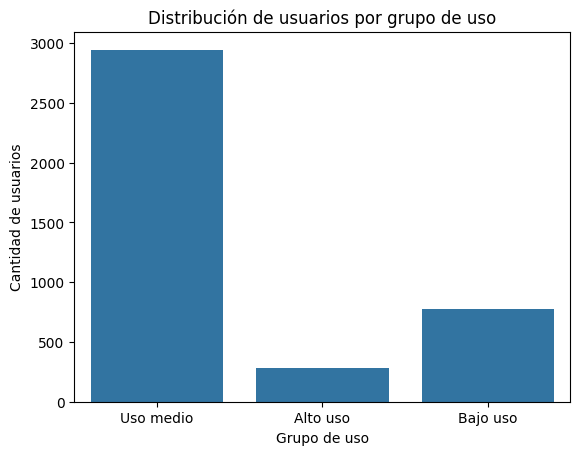

In [47]:
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

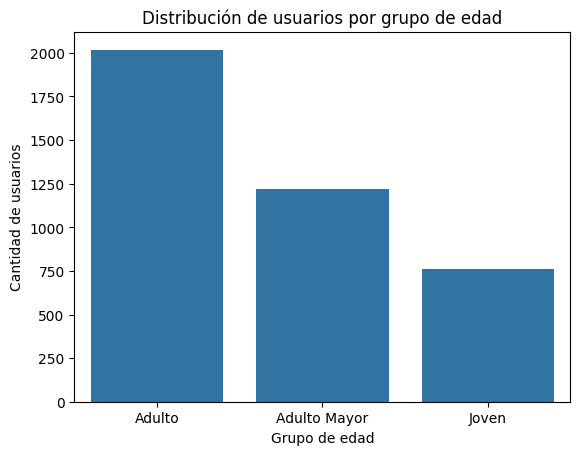

In [48]:
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

# 📊 Análisis Ejecutivo

## ⚠️ Problemas detectados en los datos

* Se identificó un valor sentinel inválido (`-999`) en la variable `age`, el cual fue tratado como un error de captura antes del análisis.
* Se detectaron 40 registros con fecha de registro en el año 2026, fuera del rango temporal esperado dado que los datos analizados corresponden hasta el año 2024.
* En la variable `city` se encontró el valor inconsistente `"?"`, que fue reemplazado por valores nulos (`NaN`) para su correcta interpretación.
* Los valores nulos observados en `duration` y `length` no corresponden a errores de calidad. Se comprobó que dependen de la variable `type`, ya que las llamadas registran duración mientras que los mensajes registran longitud. Por lo tanto, estos valores ausentes fueron considerados estructurales y se mantuvieron.

## 🔎 Segmentación por Edad

* El segmento predominante corresponde a los **Adultos**, con 2.018 usuarios (50,5% de la base).
* Los **Adultos Mayores** representan 1.222 usuarios (30,6%).
* Los **Jóvenes** constituyen el grupo menos numeroso, con 760 usuarios (19,0%).

➡️ La cartera de clientes está compuesta mayoritariamente por usuarios adultos, por lo que las estrategias comerciales y de comunicación deberían enfocarse principalmente en este segmento.

## 📈 Segmentación por Nivel de Uso

* El grupo de **Uso Medio** concentra 2.943 usuarios (73,6% de la base).
* El segmento de **Bajo Uso** reúne 778 usuarios (19,5%).
* Los usuarios de **Alto Uso** representan solo 279 clientes (7,0%).

➡️ La mayoría de los clientes presenta patrones de consumo moderados. Esto sugiere una oportunidad para desarrollar estrategias que incentiven una mayor utilización del servicio y faciliten la migración hacia planes de mayor valor.

## 📉 Patrones de uso extremo (Outliers)

* Se identificaron valores atípicos en las variables `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`.
* Aunque algunos registros superan ampliamente el límite superior calculado mediante IQR, los valores observados continúan siendo plausibles dentro del contexto del negocio y no corresponden a errores de captura.
* Por este motivo, se decidió conservarlos dentro del análisis.

➡️ Los usuarios con consumos excepcionalmente altos podrían representar clientes de alto valor y constituyen un segmento estratégico para acciones de fidelización y retención.

## 💡 Recomendaciones

* El segmento de Uso Medio concentra aproximadamente el 74% de los usuarios (2.943 clientes), por lo que representa la principal oportunidad de crecimiento. Se recomienda diseñar promociones o beneficios que incentiven un mayor consumo y faciliten la migración hacia planes de mayor valor.
* Los usuarios de Alto Uso representan solo el 7% de la base (279 clientes), pero muestran patrones de consumo significativamente superiores al promedio. Se recomienda evaluar la creación de un plan premium con mayores beneficios, más minutos o servicios adicionales que permitan fidelizar este segmento y maximizar los ingresos.
* Los usuarios de Bajo Uso (778 clientes) podrían beneficiarse de planes más económicos o flexibles, adaptados a clientes con necesidades limitadas. Esto podría reducir el riesgo de abandono por percepción de sobrepago.
* Dado que la mayor parte de la cartera está compuesta por adultos y adultos mayores (81% de los usuarios), las campañas comerciales y estrategias de comunicación deberían enfocarse principalmente en estos segmentos, adaptando tanto los canales como los beneficios ofrecidos.